In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from os import listdir
from os.path import isfile, join
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import image_functions as imf

# For better visualization
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

In [2]:
# Concatenate phenotying files into one dataframe and save to .csv
PHENOTYPE_DIR = "/mnt/isilon/shalemlab/Personal/Greg/dCas9_Optimization/20250331_NtermNLS_Timecourse/Image_Analysis/Phenotyping/cyto_sub_mean"
OUTPUT_FILE = "cells_phenotyped_cytosub_mean.csv"

df = imf.concat_phenotyping(PHENOTYPE_DIR, OUTPUT_FILE)

Found 73 CSV files


100%|██████████| 73/73 [00:00<00:00, 146.70it/s]



Successfully loaded 73/73 files

Combined dataset:
  Total cells: 2,351
  Total features: 122
  Wells: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
  Tiles per well: {1: 4, 2: 5, 3: 5, 4: 5, 5: 4, 7: 5, 8: 5, 9: 5, 10: 5, 11: 5, 13: 5, 14: 5, 15: 5, 16: 5, 17: 5}

Cells per experimental group:
  2xMeCP2NLS: 390 cells
  2xMycNLS: 417 cells
  NpNLS+2xSV40NLS: 544 cells
  Parental: 531 cells
  noNLS: 469 cells

Saved combined data to: cells_phenotyped_cytosub_mean.csv
  File size: 4.14 MB


(0.0, 5882.55)

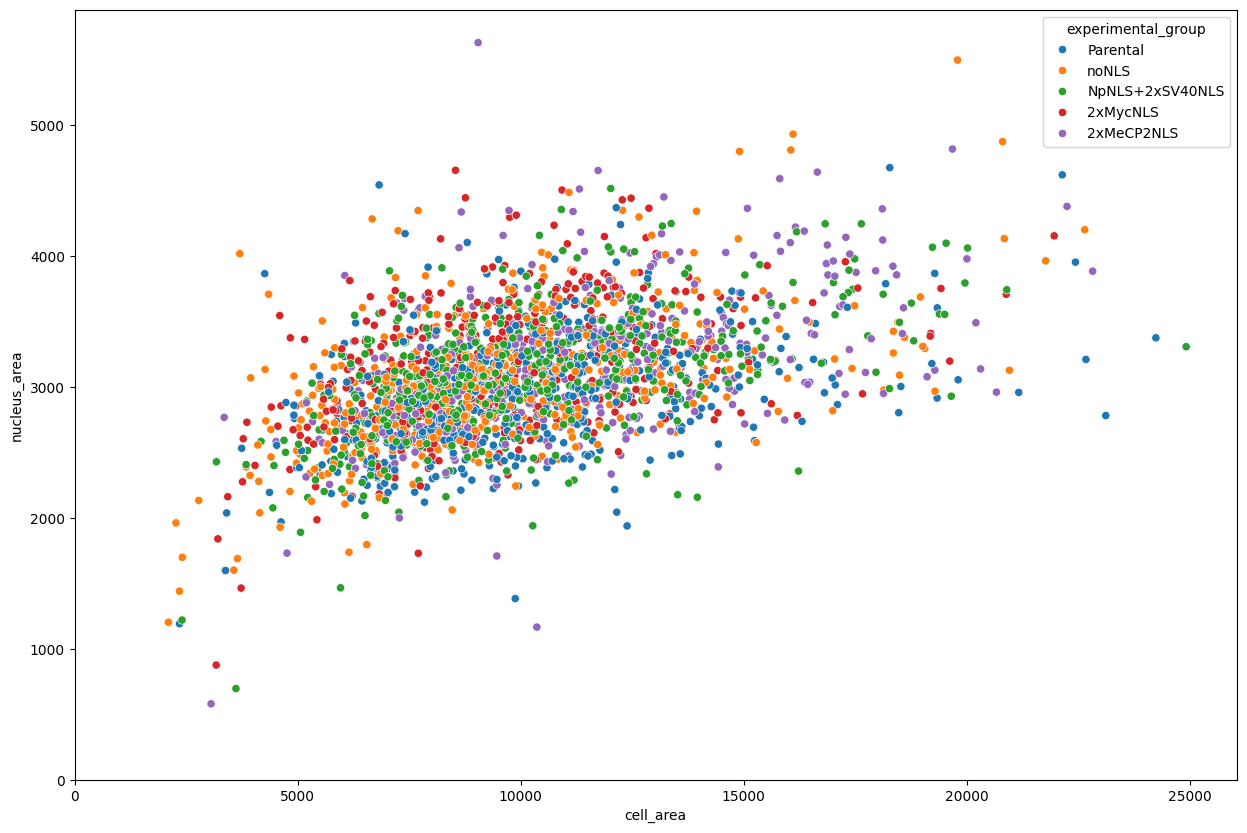

In [3]:
# Evaluate masks
#DF = df
DF = pd.read_csv("cells_phenotyed_cytosub_mean.csv")
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]

fig, axes = plt.subplots(figsize=(15,10))

sns.scatterplot(ax=axes, data=DF, x="cell_area", y="nucleus_area", hue="experimental_group", hue_order=ORDER, legend="full")
#axes.set_xscale("log")
#axes.set_yscale("log")
axes.set_xlim(0,) 
axes.set_ylim(0,)

<Axes: xlabel='experimental_group', ylabel='cell_area'>

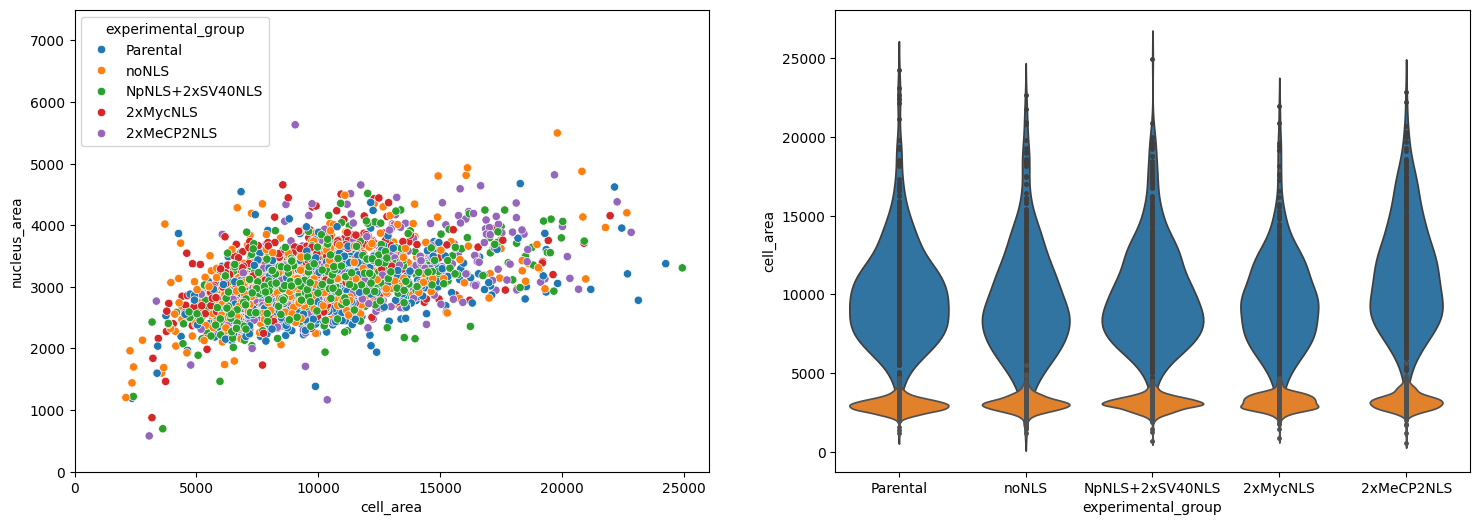

In [4]:
# Evaluate masks
fig, axes = plt.subplots(1, 2, figsize=(18,6))

sns.scatterplot(ax=axes[0], data=DF, x="cell_area", y="nucleus_area", hue="experimental_group", hue_order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], legend="full")
axes[0].set_xlim(0,26000) 
axes[0].set_ylim(0,7500)

sns.violinplot(ax=axes[1], data=DF, x="experimental_group", y="cell_area", order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], inner="point", density_norm="count")
sns.violinplot(ax=axes[1], data=DF, x="experimental_group", y="nucleus_area", order=["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"], inner="point", density_norm="count")

In [5]:
# Filter cells based on masks:
#DF = df
DF = pd.read_csv("cells_phenotyed_cytosub_mean.csv")
MIN_NUC_AREA = 1750
MAX_NUC_AREA = 4500
#MIN_CELL_AREA =
MAX_NUC_RATIO = 2/3

df_filtered = imf.filter_by_quality(DF, 
                                    min_nucleus_area=MIN_NUC_AREA,
                                    max_nucleus_area=MAX_NUC_AREA,
                                    #min_cell_area=MIN_CELL_AREA,
                                    max_nuc_to_cell_ratio=MAX_NUC_RATIO,
                                    edge_buffer=0
                                   )

Filtered 51 cells (2.2%)
Remaining: 2,300 cells


In [6]:
# Inspect filtered dataset:
imf.summarize_dataset(df_filtered)

DATASET SUMMARY

Dimensions:
  Rows (cells): 2,300
  Columns (features): 122

Wells:
  Number of wells: 15
  Well IDs: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

Tiles:
  Total unique tiles: 5
  Tiles per well:
    Well 1: 4 tiles
    Well 2: 5 tiles
    Well 3: 5 tiles
    Well 4: 5 tiles
    Well 5: 4 tiles
    Well 7: 5 tiles
    Well 8: 5 tiles
    Well 9: 5 tiles
    Well 10: 5 tiles
    Well 11: 5 tiles
    Well 13: 5 tiles
    Well 14: 5 tiles
    Well 15: 5 tiles
    Well 16: 5 tiles
    Well 17: 5 tiles

Experimental Groups:
  2xMeCP2NLS: 379 cells from 3 wells
  2xMycNLS: 408 cells from 3 wells
  NpNLS+2xSV40NLS: 539 cells from 3 wells
  Parental: 523 cells from 3 wells
  noNLS: 451 cells from 3 wells

Measurement Categories:
  Nucleus features: 43
  Cell features: 43
  Cytoplasm features: 29
  Ratio features: 4

Data completeness:
  Missing values: 0 (0.00%)

Matching labels:
  Nucleus-Cell matches: 2300/2300 (100.0%)


<Axes: xlabel='experimental_group', ylabel='cell_area'>

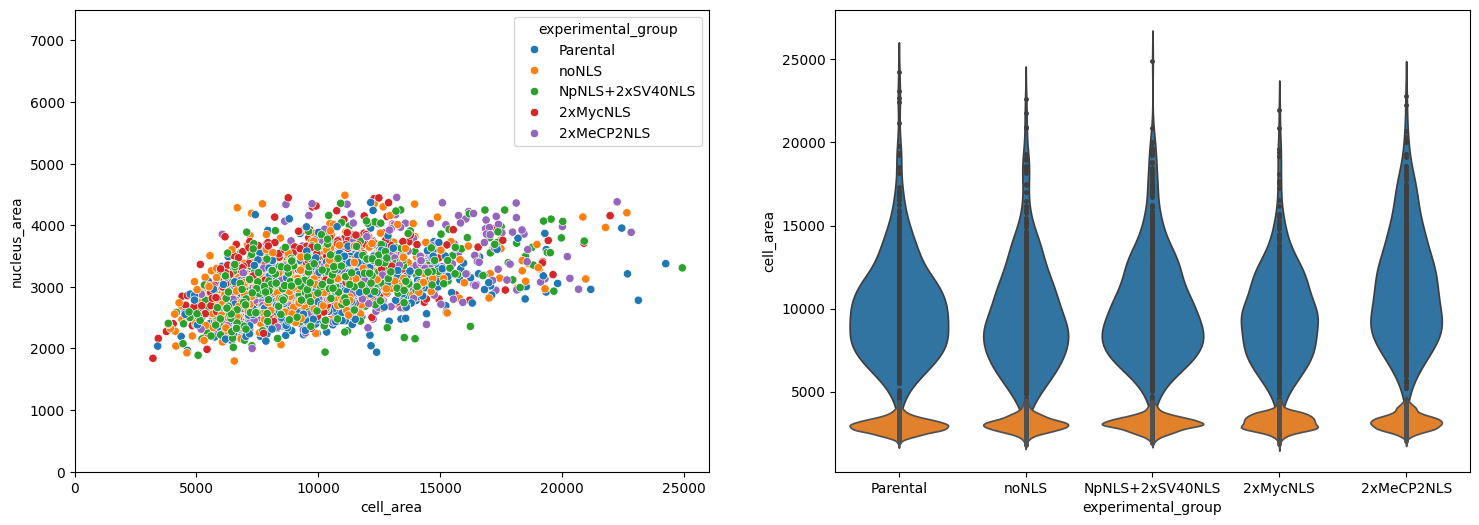

In [7]:
# Evaluate filtered masks
DF = df_filtered
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]

fig, axes = plt.subplots(1, 2, figsize=(18,6))

sns.scatterplot(ax=axes[0], data=DF, x="cell_area", y="nucleus_area", hue="experimental_group", hue_order=ORDER, legend="full")
axes[0].set_xlim(0,26000) 
axes[0].set_ylim(0,7500)

sns.violinplot(ax=axes[1], data=DF, x="experimental_group", y="cell_area", order=ORDER, inner="point", density_norm="count")
sns.violinplot(ax=axes[1], data=DF, x="experimental_group", y="nucleus_area", order=ORDER, inner="point", density_norm="count")

<Axes: xlabel='experimental_group', ylabel='cell_MAP2_mean_intensity'>

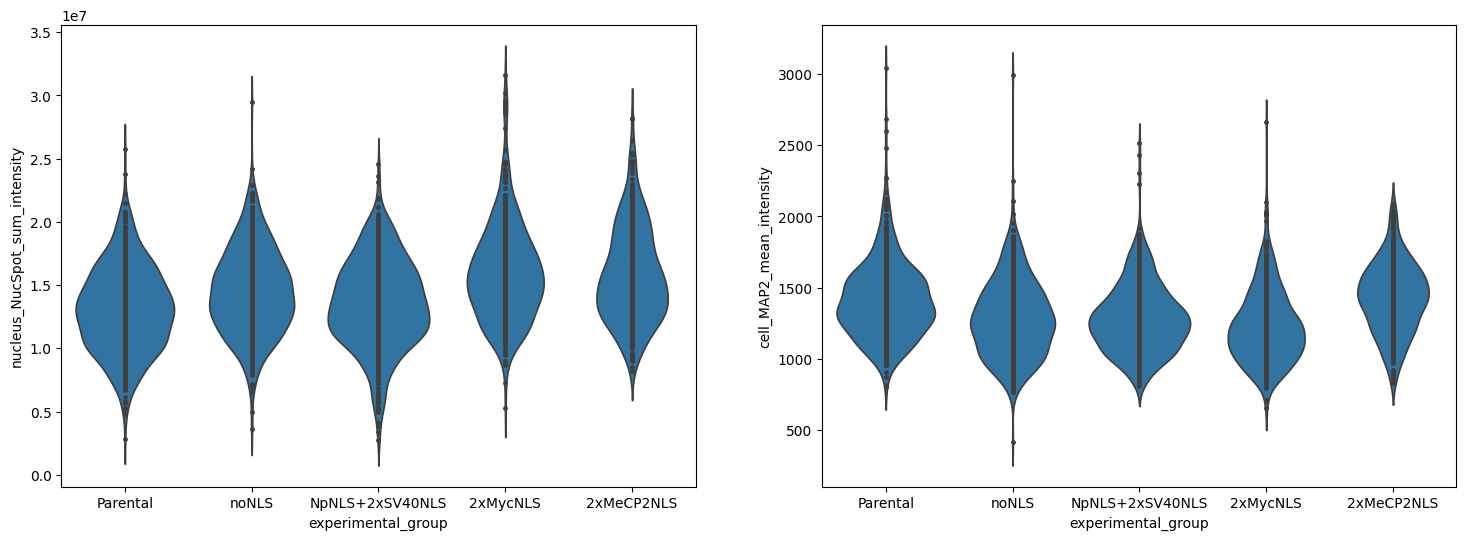

In [8]:
# Evaluate cell and nuclear staining in filtered masks
DF = df_filtered
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]

fig, axes = plt.subplots(1, 2, figsize=(18,6))

sns.violinplot(ax=axes[0], data=DF, x="experimental_group", y="nucleus_NucSpot_sum_intensity", order=ORDER, inner="point", density_norm="count")
sns.violinplot(ax=axes[1], data=DF, x="experimental_group", y="cell_MAP2_mean_intensity", order=ORDER, inner="point", density_norm="count")

<Axes: xlabel='nucleus_area', ylabel='nucleus_NucSpot_sum_intensity'>

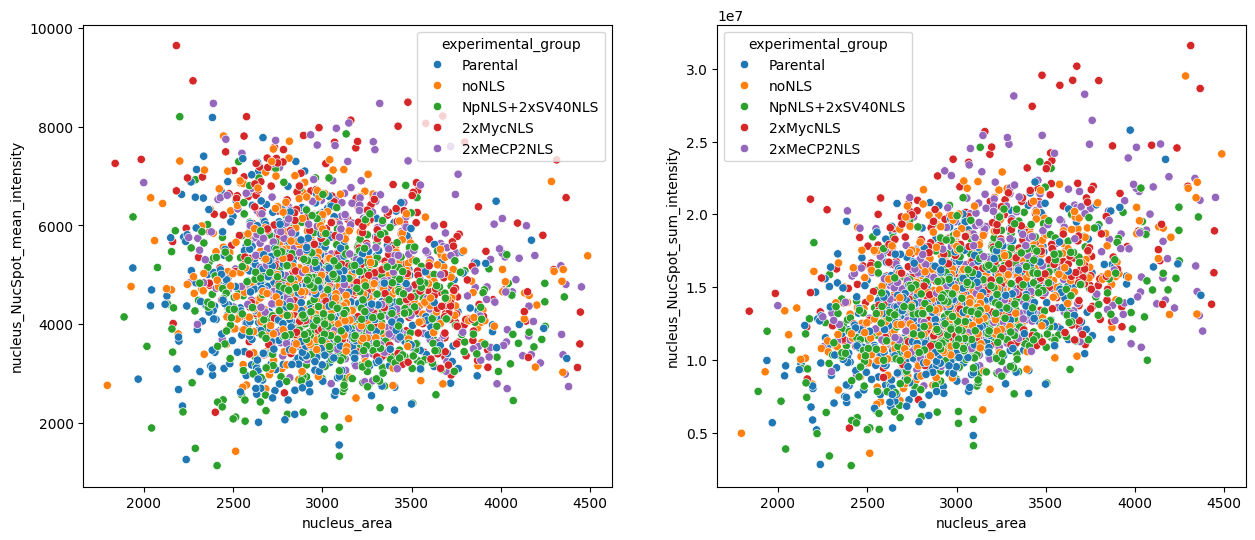

In [9]:
# Evaluate filtered cells for nuclear stain correlations
DF = df_filtered
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "NucSpot"
COMPARTMENT = "nucleus"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"{COMPARTMENT}_area", y=f"nucleus_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"{COMPARTMENT}_area", y=f"nucleus_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

#axes[0].set_xlim(0,) 
#axes[0].set_ylim(0,)

#axes[1].set_xlim(0,) 
#axes[1].set_ylim(0,)

<Axes: xlabel='cytoplasm_area', ylabel='nucleus_MAP2_sum_intensity'>

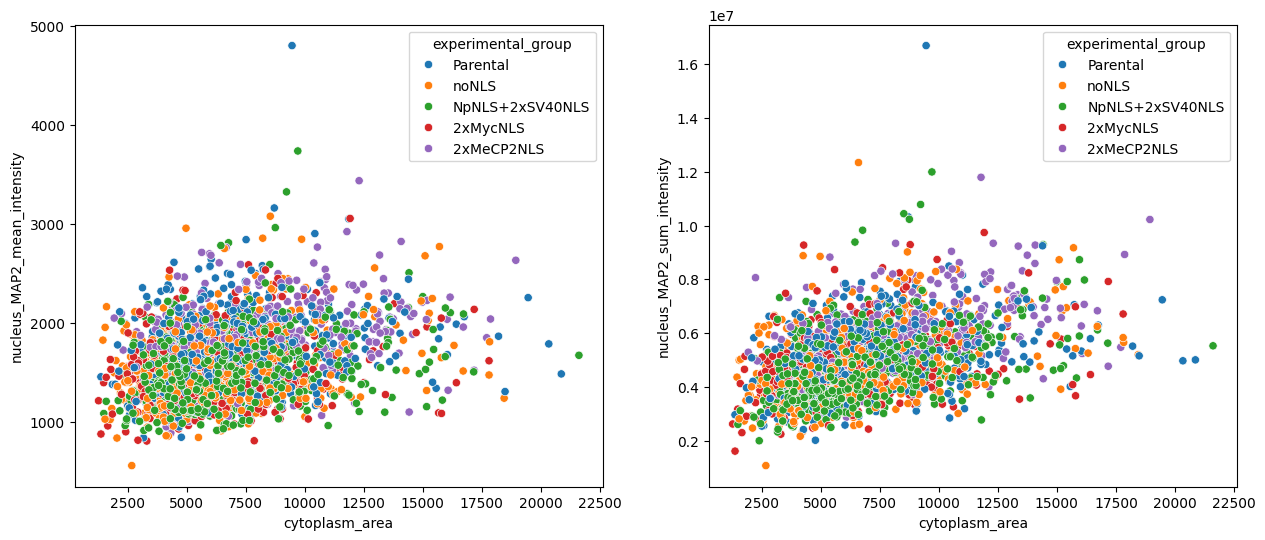

In [10]:
# Evaluate filtered cells for cell stain correlations
DF = df_filtered
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "MAP2"
COMPARTMENT = "cytoplasm"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"{COMPARTMENT}_area", y=f"nucleus_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"{COMPARTMENT}_area", y=f"nucleus_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

#axes[0].set_xlim(0,) 
#axes[0].set_ylim(0,)

#axes[1].set_xlim(0,) 
#axes[1].set_ylim(0,)

(0.0, 6702830.166666667)

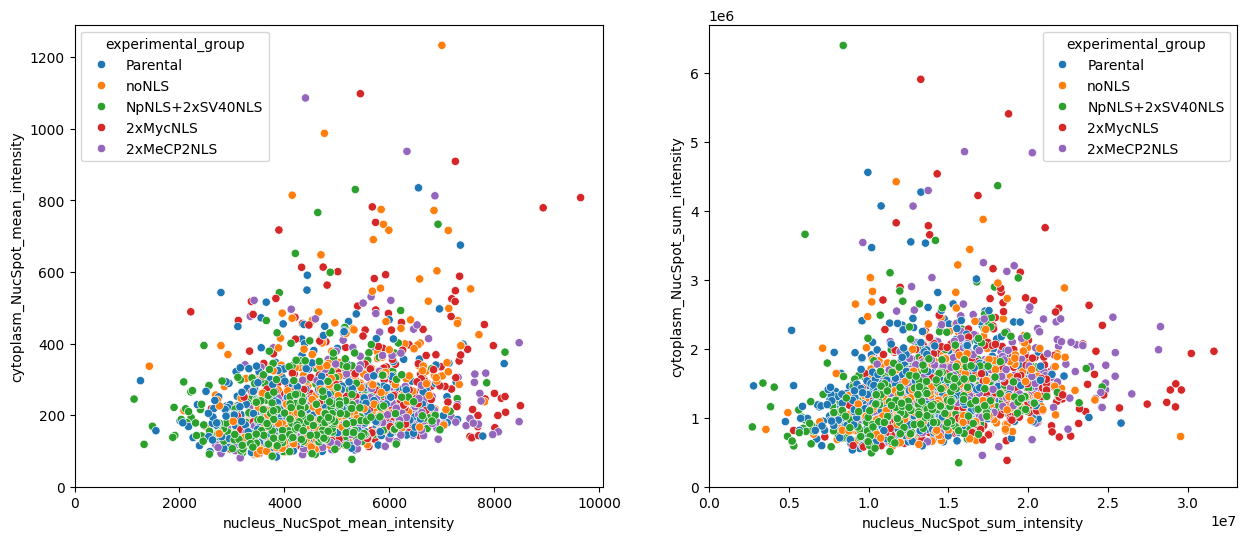

In [11]:
# Evaluate filtered cells for nuclear staining artifacts
DF = df_filtered
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "NucSpot"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"nucleus_{CHANNEL_NAME}_mean_intensity", y=f"cytoplasm_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"nucleus_{CHANNEL_NAME}_sum_intensity", y=f"cytoplasm_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

axes[0].set_xlim(0,) 
axes[0].set_ylim(0,)

axes[1].set_xlim(0,) 
axes[1].set_ylim(0,)

(0.0, 1291.7476485308998)

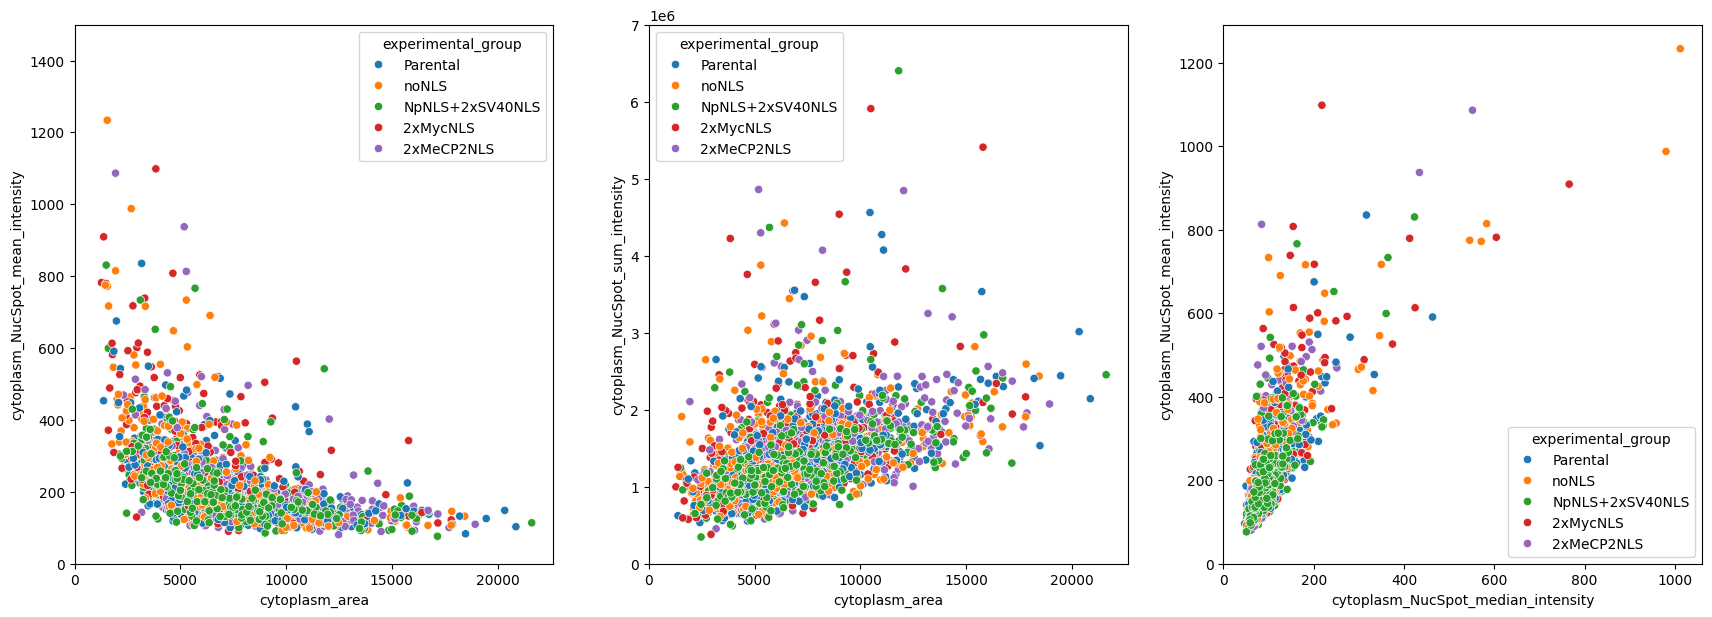

In [12]:
# Evaluate filtered cells for nuclear staining artifacts
DF = df_filtered
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "NucSpot"

fig, axes = plt.subplots(1, 3, figsize=(21,7))

sns.scatterplot(ax=axes[0], data=DF, x="cytoplasm_area", y=f"cytoplasm_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x="cytoplasm_area", y=f"cytoplasm_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[2], data=DF, x=f"cytoplasm_{CHANNEL_NAME}_median_intensity", y=f"cytoplasm_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)

#LOG_CYTO_AREA = np.log10(DF["cytoplasm_area"]-DF["cytoplasm_area"].min()+1)

#sns.lineplot(ax=axes[0], data=DF, x="cytoplasm_area", y=(1.01**((DF[f"cytoplasm_{CHANNEL_NAME}_mean_intensity"].mean())/LOG_CYTO_AREA*10)))

axes[0].set_xlim(0,) 
axes[0].set_ylim(0,1500)

axes[1].set_xlim(0,) 
axes[1].set_ylim(0,7000000)

axes[2].set_xlim(0,) 
axes[2].set_ylim(0,)
#axes[1].set_yscale("log")

In [13]:
# Filter cells again to account for nuclear staining artifacts
#df_filtered_new = df_filtered[df_filtered["cytoplasm_NucSpot_sum_intensity"] < 2750000]
df_filtered_new = df_filtered[(df_filtered["cytoplasm_NucSpot_sum_intensity"]-df_filtered["cytoplasm_NucSpot_sum_intensity"].mean())/(df_filtered["cytoplasm_area"]) < df_filtered["cytoplasm_NucSpot_mean_intensity"].mean()*0.5].copy()
#df_filtered_new = df_filtered_new[df_filtered_new["cytoplasm_NucSpot_sum_intensity"]/df_filtered_new["cytoplasm_area"] < df_filtered_new["cytoplasm_NucSpot_mean_intensity"]*110]

print(df_filtered.shape)
print(df_filtered_new.shape)

(2300, 122)
(2187, 122)


(0.0, 951.0007455280204)

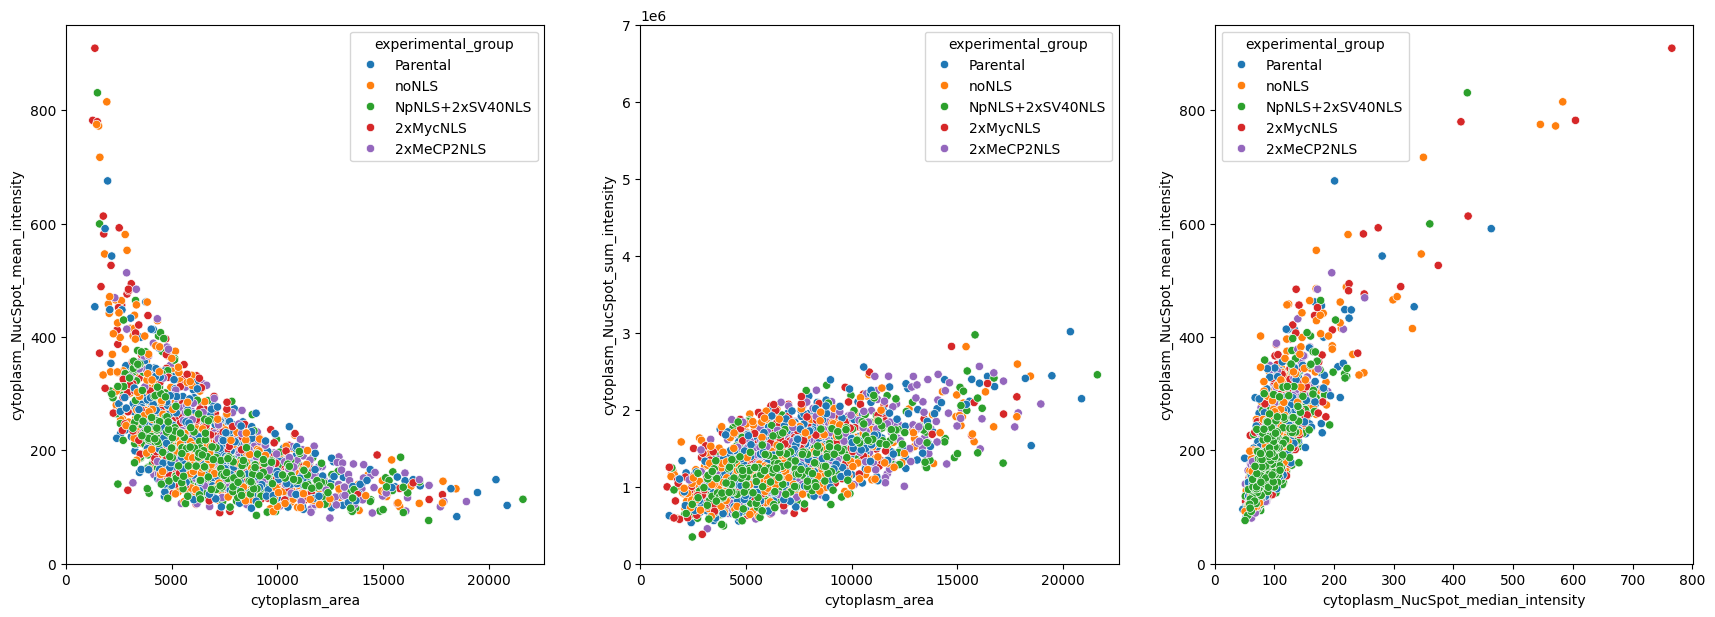

In [14]:
# Evaluate newly filtered cells
DF = df_filtered_new
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "NucSpot"

fig, axes = plt.subplots(1, 3, figsize=(21,7))

sns.scatterplot(ax=axes[0], data=DF, x="cytoplasm_area", y=f"cytoplasm_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x="cytoplasm_area", y=f"cytoplasm_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[2], data=DF, x=f"cytoplasm_{CHANNEL_NAME}_median_intensity", y=f"cytoplasm_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)

axes[0].set_xlim(0,) 
axes[0].set_ylim(0,)

axes[1].set_xlim(0,) 
axes[1].set_ylim(0,7000000)

axes[2].set_xlim(0,) 
axes[2].set_ylim(0,)
#axes[1].set_yscale("log")

(0.0, 2998354.725)

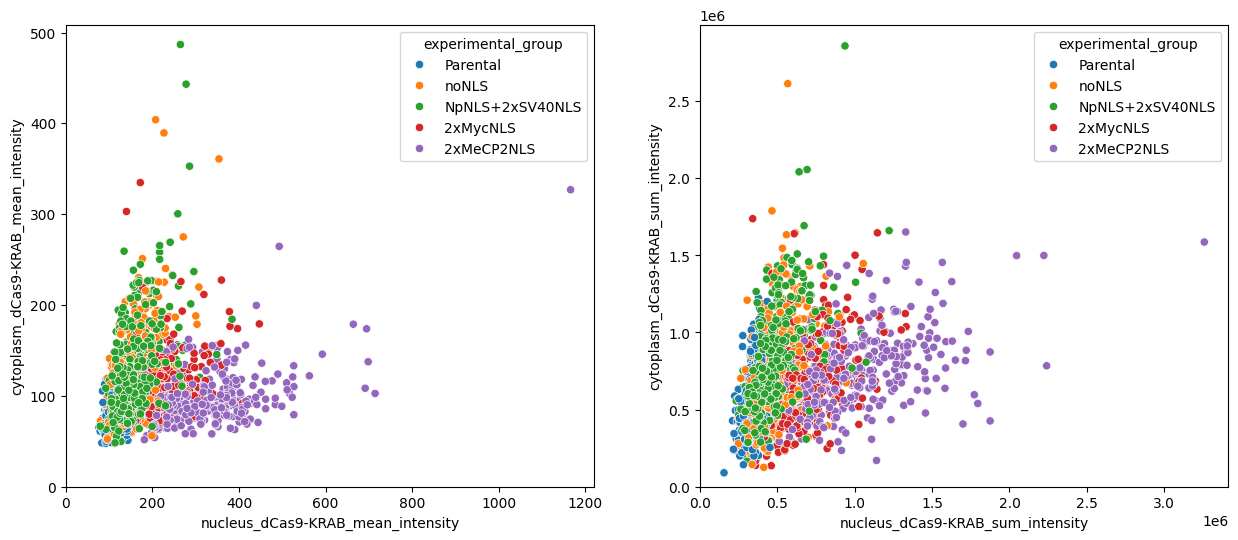

In [15]:
# Evaluate experimental staining in filtered masks
DF = df_filtered_new
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x="nucleus_dCas9-KRAB_mean_intensity", y="cytoplasm_dCas9-KRAB_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x="nucleus_dCas9-KRAB_sum_intensity", y="cytoplasm_dCas9-KRAB_sum_intensity", hue="experimental_group", hue_order=ORDER)

axes[0].set_xlim(0,) 
axes[0].set_ylim(0,)

axes[1].set_xlim(0,) 
axes[1].set_ylim(0,)

(0.0, 2998354.725)

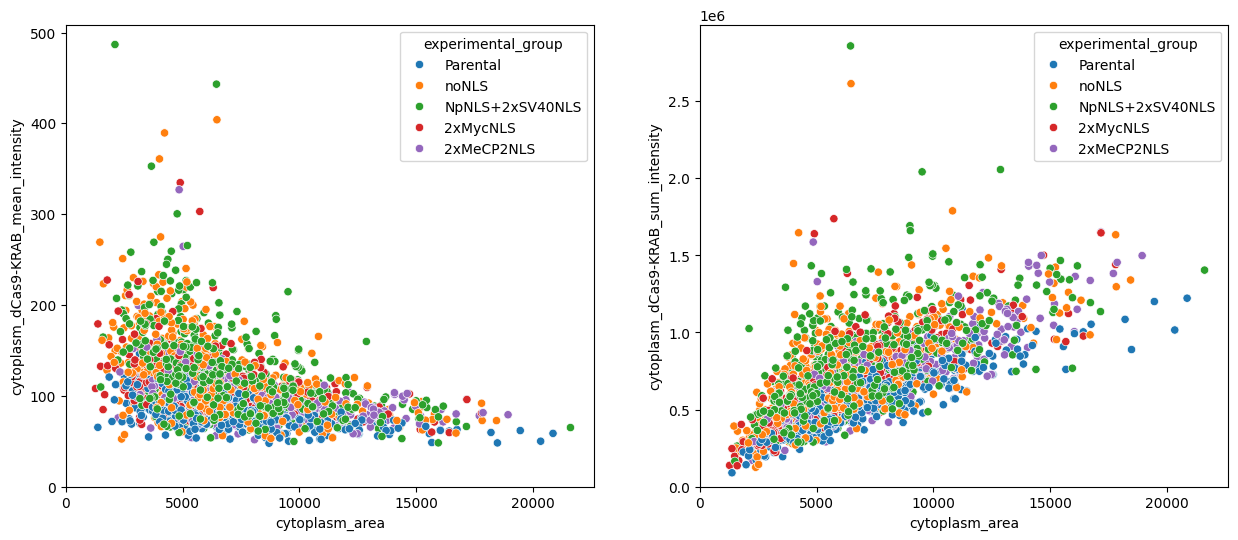

In [16]:
# Evaluate filtered cells for dCas9-KRAB correlations: cytoplasm
DF = df_filtered_new
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "cytoplasm"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"{COMPARTMENT}_area", y=f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"{COMPARTMENT}_area", y=f"{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

axes[0].set_xlim(0,) 
axes[0].set_ylim(0,)

axes[1].set_xlim(0,) 
axes[1].set_ylim(0,)

In [17]:
# Normalize to minimum measured values: cytoplasm
DF = df_filtered_new
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "cytoplasm"

# Normed mean: subtract min mean_intensity from each mean
DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"] = DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"] - DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].min() + 1
print(DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].min(), DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].max())
print(DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].min(), DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].max())

# Normed median: subtract min median_intensity from each median
DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"] = DF[f"{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"] - DF[f"{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"].min() + 1
print(DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"].min(), DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"].max())

# Normed sum: multiply min_norm_mean_intensity by mask area
DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity"] = DF[f"{COMPARTMENT}_area"]*DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"]
print(DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity"].min(), DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity"].max())

df_filtered_new = DF

47.76686200160864 486.8985438429883
1.0 440.1316818413797
1.0 418.75
8703.0 2558103.706365621


(0.0, 2685573.741683902)

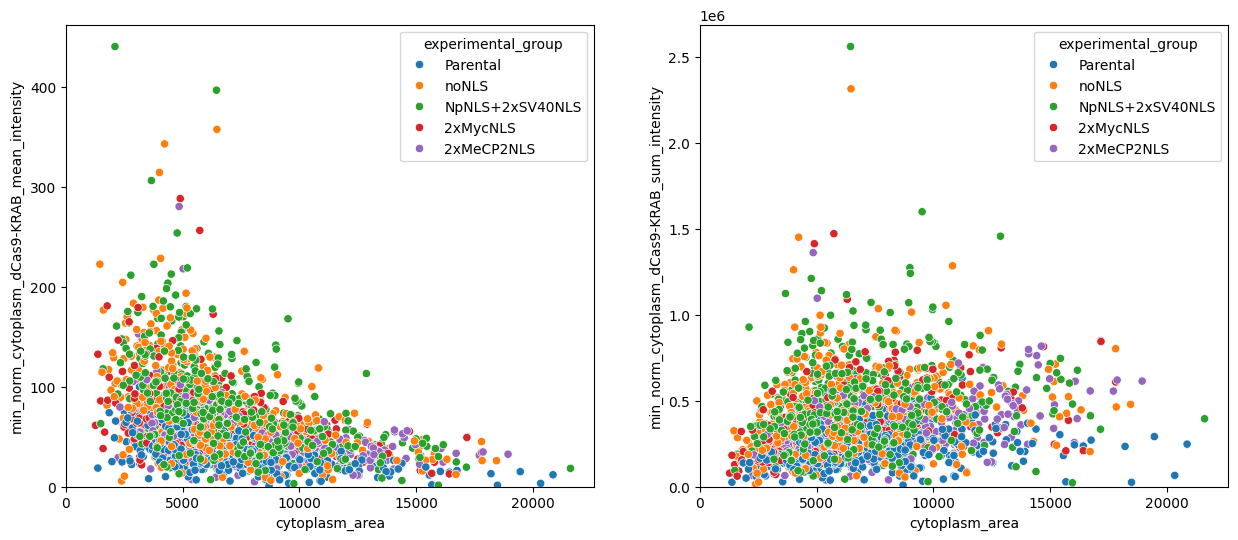

In [18]:
# Evaluate normalizations for dCas9-KRAB: cytoplasm
DF = df_filtered_new
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "cytoplasm"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"{COMPARTMENT}_area", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"{COMPARTMENT}_area", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

axes[0].set_xlim(0,) 
axes[0].set_ylim(0,)

axes[1].set_xlim(0,) 
axes[1].set_ylim(0,)

<Axes: xlabel='nucleus_area', ylabel='nucleus_dCas9-KRAB_sum_intensity'>

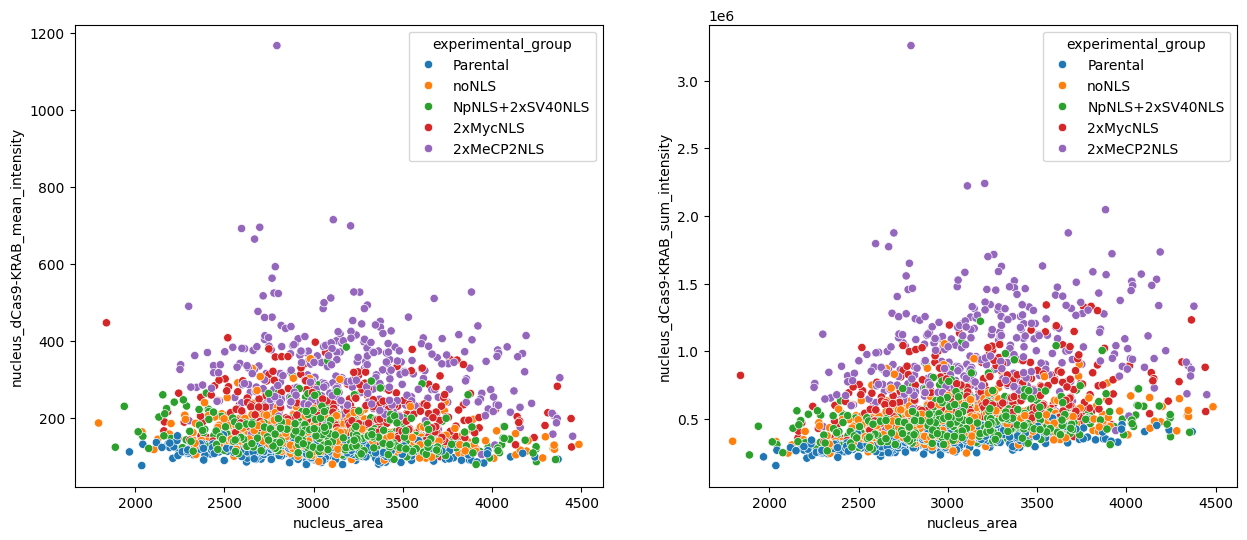

In [19]:
# Evaluate filtered cells for dCas9-KRAB correlations
DF = df_filtered_new
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "nucleus"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"{COMPARTMENT}_area", y=f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"{COMPARTMENT}_area", y=f"{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

#axes[0].set_xlim(0,) 
#axes[0].set_ylim(0,)

#axes[1].set_xlim(0,) 
#axes[1].set_ylim(0,)

In [20]:
# Normalize to minimum measured values: nucleus
DF = df_filtered_new
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "nucleus"

# Normed mean: subtract min mean_intensity from each mean
DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"] = DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"] - DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].min() + 1
print(DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].min(), DF[f"{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].max())
print(DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].min(), DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"].max())

# Normed median: subtract min median_intensity from each median
DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"] = DF[f"{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"] - DF[f"{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"].min() + 1
print(DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"].min(), DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_median_intensity"].max())

# Normed sum: multiply min_norm_mean_intensity by mask area
DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity"] = DF[f"{COMPARTMENT}_area"]*DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity"]
print(DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity"].min(), DF[f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity"].max())

df_filtered_new = DF

76.569137620684 1166.1494273443093
1.0 1090.5802897236254
1.0 1155.6666666666667
2037.0 3047081.3294878094


<Axes: xlabel='nucleus_area', ylabel='min_norm_nucleus_dCas9-KRAB_sum_intensity'>

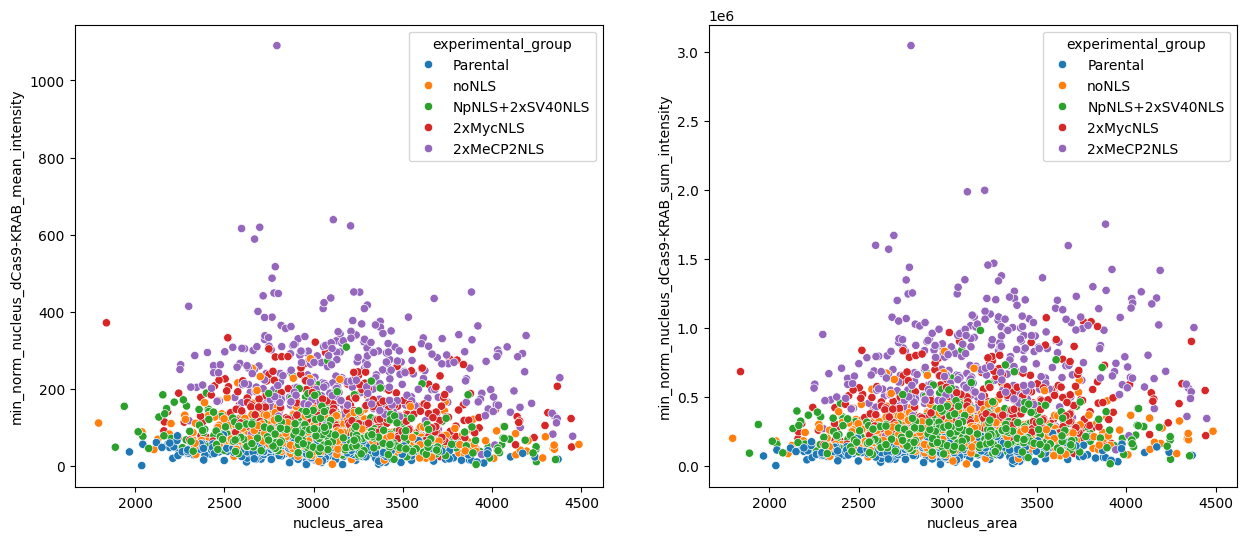

In [21]:
# Evaluate normalizations for dCas9-KRAB: cytoplasm
DF = df_filtered_new
ORDER = ["Parental", "noNLS", "NpNLS+2xSV40NLS", "2xMycNLS", "2xMeCP2NLS"]
CHANNEL_NAME = "dCas9-KRAB"
COMPARTMENT = "nucleus"

fig, axes = plt.subplots(1, 2, figsize=(15,6))

sns.scatterplot(ax=axes[0], data=DF, x=f"{COMPARTMENT}_area", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_mean_intensity", hue="experimental_group", hue_order=ORDER)
sns.scatterplot(ax=axes[1], data=DF, x=f"{COMPARTMENT}_area", y=f"min_norm_{COMPARTMENT}_{CHANNEL_NAME}_sum_intensity", hue="experimental_group", hue_order=ORDER)

#axes[0].set_xlim(0,) 
#axes[0].set_ylim(0,)

#axes[1].set_xlim(0,) 
#axes[1].set_ylim(0,)

In [22]:
# Check filtered dataset
imf.summarize_dataset(df_filtered)
imf.summarize_dataset(df_filtered_new)

DATASET SUMMARY

Dimensions:
  Rows (cells): 2,300
  Columns (features): 122

Wells:
  Number of wells: 15
  Well IDs: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]

Tiles:
  Total unique tiles: 5
  Tiles per well:
    Well 1: 4 tiles
    Well 2: 5 tiles
    Well 3: 5 tiles
    Well 4: 5 tiles
    Well 5: 4 tiles
    Well 7: 5 tiles
    Well 8: 5 tiles
    Well 9: 5 tiles
    Well 10: 5 tiles
    Well 11: 5 tiles
    Well 13: 5 tiles
    Well 14: 5 tiles
    Well 15: 5 tiles
    Well 16: 5 tiles
    Well 17: 5 tiles

Experimental Groups:
  2xMeCP2NLS: 379 cells from 3 wells
  2xMycNLS: 408 cells from 3 wells
  NpNLS+2xSV40NLS: 539 cells from 3 wells
  Parental: 523 cells from 3 wells
  noNLS: 451 cells from 3 wells

Measurement Categories:
  Nucleus features: 43
  Cell features: 43
  Cytoplasm features: 29
  Ratio features: 4

Data completeness:
  Missing values: 0 (0.00%)

Matching labels:
  Nucleus-Cell matches: 2300/2300 (100.0%)
DATASET SUMMARY

Dimensions:
  Rows (cells): 2

In [23]:
# Save newly filtered cell dataframe
df_filtered_new.to_csv("cells_phenotyped_cytosub_mean_filtered_final.csv", index=False)